# library

In [2]:
using OffsetArrays, Plots, LinearAlgebra, Statistics, Revise, ProgressMeter, JLD2
include("oggetti.jl")
include("gillespie_temp.jl")

path_data = "data/fundamental_diagram/"
path_image = "images/fundamental_diagram/"


"C:\\Users\\franc\\OneDrive\\Desktop\\TESI_PELLIZZOLA\\TESTO TESI\\Politecnico_di_Torino___Thesis_Template\\images\\imm_chapter_3\\fundamental_diagram\\"

# Current as a function of ρ, fundamental diagram

I want to reproduce the fundamental diagram $J(\rho)= \rho(1-\rho)$ in a system with q=0.5 for each method and compare the results.
ρ has a linear profile when the system is set with $\beta = 1-\alpha$, and $\rho$ takes the same value as $\alpha$, so I can write $J(\alpha)$.


PLAN:
- run tests at L = 50 (chosen to speed up gillespie; Fulvio also used 50 in his tests)


EXPECTATION:
- the approximations should have an increasingly higher plateau, but not reach the one from gillespie

QUESTIONS:
- does anything change if I change q_def? => theoretically no
- does anything change if I change the defect length $L_q$? => not sure


# current function


In [3]:

function current_ρ(α_values;
    methods=["MF", "PA", "TRI", "GILL"],
    L=50, q_defect=0.5,
    cond_init=(0.5, 0.0), cond_init_tri=(0.5, 0.25, 0.25, 0.25),
    defect1_length=1,
    from=:center,
    termalization_time=1e7,
)

    currents = Dict{String,Vector{Float64}}()
    densities = Dict{String,Vector{Any}}()

    for method in methods
        currents[method] = Float64[]
        densities[method] = Float64[]
    end
    q = lattice(L, q_defect, defect1_length, from)

    @showprogress for α in α_values
        tasep = Tasep(L, α, 1 - α, q)  # example tasep with variable q

        if "MF" in methods
            ρ, J = EuleroMF(tasep, cond_init)
            push!(currents["MF"], copy(mean(J)))
            push!(densities["MF"], copy(mean(ρ)))

        end

        if "PA" in methods
            ρ, J = EuleroPA(tasep, cond_init)
            push!(currents["PA"], copy(mean(J)))
            push!(densities["PA"], copy(mean(ρ)))

        end

        if "TRI" in methods
            ρ, J, _, _ = EuleroTRI(tasep, cond_init_tri)
            push!(currents["TRI"], copy(mean(J)))
            push!(densities["TRI"], copy(mean(ρ)))
        end


        if "GILL" in methods


            #=
            if α == 0.45555555555555555 || α == 0.5444444444444444

                termalization_time = 1e9
            else
                termalization_time = 1e5
            end
            =#
            termalization_time = 1e5

            ρ, J = Gillespie_temp(tasep, cond_init; termalization_time=termalization_time, n_measures=1e7)
            push!(currents["GILL"], copy(mean(J)))
            push!(densities["GILL"], copy(ρ))
        end
    end

    return densities, currents
end


current_ρ (generic function with 1 method)

# plot

## plot, 0 defects


In [4]:
α_values = collect(range(0.1, 0.9, 31));

#densities, currents = current_ρ(α_values; methods=["MF","PA" ,"TRI","GILL"], L=50, q_defect=1);

name_data = "currents_densities_TASEP_PURO.jld2"
#@save path_data*name_data currents densities
@load path_data * name_data currents densities

2-element Vector{Symbol}:
 :currents
 :densities

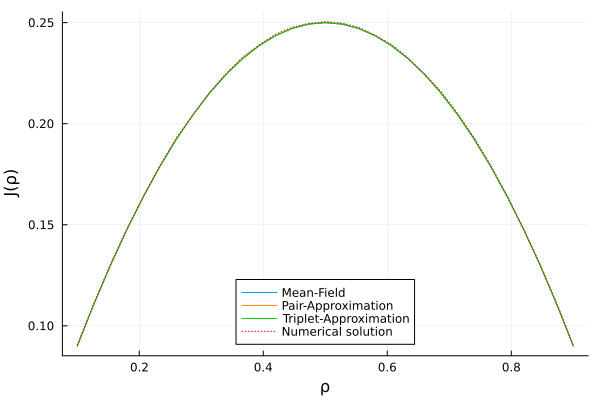

In [5]:
p = plot(xlabel="ρ",
    ylabel="J(ρ)",
    lw=2,
    legend=:bottom)
plot!(p, α_values, currents["MF"], label="Mean-Field",)
plot!(p, α_values, currents["PA"], label="Pair-Approximation", color=:darkorange)
plot!(p, α_values, currents["TRI"], label="Triplet-Approximation", color=:green3)
plot!(p, α_values, currents["GILL"], label="Numerical solution", color=:crimson, lw=1, ls=:dot)

In [6]:
savefig(p, path_image * "fundamental_diagram_TASEP_puro.png")

"C:\\Users\\franc\\OneDrive\\Desktop\\TESI_PELLIZZOLA\\TESTO TESI\\Politecnico_di_Torino___Thesis_Template\\images\\imm_chapter_3\\fundamental_diagram\\fundamental_diagram_TASEP_puro.png"

## plot, single defect q = 0.25


In [7]:
α_values = collect(range(0.1, 0.9, 31));

# densities, currents = current_ρ(α_values; methods=["MF","PA" ,"TRI","GILL"], L=50, q_defect=0.25);
name_data = "currents_densities_TASEP_IMPURO_025.jld2"
#@save path_data*name_data currents densities
@load path_data * name_data currents densities

2-element Vector{Symbol}:
 :currents
 :densities

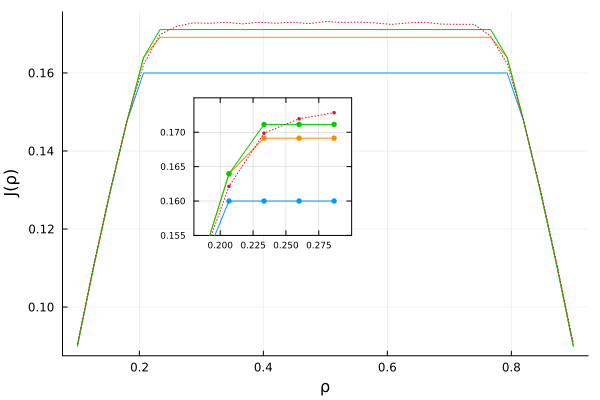

In [8]:
p = plot(xlabel="ρ",
    ylabel="J(ρ)",
    lw=2,
    legend=:bottom)
plot!(p, α_values, currents["MF"], label="")
plot!(p, α_values, currents["PA"], label="", color=:darkorange)
plot!(p, α_values, currents["TRI"], label="", color=:green3)
plot!(p, α_values, currents["GILL"], label="", color=:crimson, lw=1, ls=:dot)
# zoom
   zoom_min, zoom_max = 0.18, 0.30
    zoom_range = findall(α -> zoom_min <= α <= zoom_max, α_values)
    zoom_alphas = α_values[zoom_range]

    x, y = 0.25, 0.25
    width, height = 0.3, 0.4

    # Only create the inset, nothing else
    plot!(p, inset=(1, bbox(x, y, width, height)))

    plot!(p[2], zoom_alphas, currents["MF"][zoom_range], label="",
        legend=false,
        titlefontsize=8,
        tickfontsize=6,
        ylims=(0.155, 0.175),
        xlims=(zoom_min, zoom_max),
        framestyle=:box,
        marker=:circle, markersize=3, markerstrokewidth=0)
    plot!(p[2], zoom_alphas, currents["PA"][zoom_range], label="", color=:darkorange,
        marker=:circle, markersize=3, markerstrokewidth=0)
    plot!(p[2], zoom_alphas, currents["TRI"][zoom_range], label="", color=:green3,
        marker=:circle, markersize=3, markerstrokewidth=0)
    plot!(p[2], zoom_alphas, currents["GILL"][zoom_range], label="", color=:crimson, lw=1, ls=:dot,
        marker=:circle, markersize=2, markerstrokewidth=0)

In [9]:
savefig(p, path_image * "fundamental_diagram_TASEP_impuro.png")


"C:\\Users\\franc\\OneDrive\\Desktop\\TESI_PELLIZZOLA\\TESTO TESI\\Politecnico_di_Torino___Thesis_Template\\images\\imm_chapter_3\\fundamental_diagram\\fundamental_diagram_TASEP_impuro.png"

In [10]:
0.5 / (1.5)^2

0.2222222222222222